In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch, json
import numpy as np

class Config:
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    FINANCIAL_ANNOT = os.path.join(PROJECT_ROOT, 'data/financial_test/annotations')
    FINANCIAL_IMGS  = os.path.join(PROJECT_ROOT, 'data/financial_test/images/manual')
    MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
    PIX2STRUCT_ID   = 'google/pix2struct-docvqa-base'
    LORA_RANK       = 16
    LORA_ALPHA      = 32
    LEARNING_RATE   = 5e-5
    WEIGHT_DECAY    = 0.01
    EPOCHS          = 10
    SEED            = 42

cfg = Config()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
✓ GPU: Tesla T4
  Memory: 15.6 GB


In [2]:
# ============================================================
# CELL 2: Install + Split dataset into train/test
# ============================================================

%%capture
!pip install transformers accelerate sentencepiece protobuf peft

# ---
import json
import numpy as np
from collections import Counter

with open(os.path.join(cfg.FINANCIAL_ANNOT, 'combined_financial_vqa_dataset_fixed_types.json'), 'r') as f:
    all_data = json.load(f)

# Split by company: 7 companies for train, 3 for test
# This ensures no data leakage — test companies are never seen during training
np.random.seed(cfg.SEED)

all_tickers = list(set(entry['ticker'] for entry in all_data))
np.random.shuffle(all_tickers)

# Use 7 for training, 3 for testing
train_tickers = all_tickers[:7]
test_tickers = all_tickers[7:]

train_entries = [e for e in all_data if e['ticker'] in train_tickers]
test_entries = [e for e in all_data if e['ticker'] in test_tickers]

train_pairs = []
for entry in train_entries:
    for q in entry['questions']:
        train_pairs.append({
            'image_path': os.path.join(cfg.FINANCIAL_IMGS, entry['ticker'], entry['image_path']),
            'question': q['question'],
            'answer': q['answer'],
            'question_type': q['type'],
            'ticker': entry['ticker'],
        })

test_pairs = []
for entry in test_entries:
    for q in entry['questions']:
        test_pairs.append({
            'image_path': os.path.join(cfg.FINANCIAL_IMGS, entry['ticker'], entry['image_path']),
            'question': q['question'],
            'answer': q['answer'],
            'question_type': q['type'],
            'ticker': entry['ticker'],
        })

# Verify all images exist
train_missing = sum(1 for p in train_pairs if not os.path.exists(p['image_path']))
test_missing = sum(1 for p in test_pairs if not os.path.exists(p['image_path']))

print(f"Train companies: {sorted(train_tickers)}")
print(f"Test companies:  {sorted(test_tickers)}")
print(f"\nTrain: {len(train_entries)} images, {len(train_pairs)} QA pairs (missing: {train_missing})")
print(f"Test:  {len(test_entries)} images, {len(test_pairs)} QA pairs (missing: {test_missing})")

print(f"\nTrain question types:")
for t, c in Counter(p['question_type'] for p in train_pairs).most_common():
    print(f"  {t}: {c}")

print(f"\nTest question types:")
for t, c in Counter(p['question_type'] for p in test_pairs).most_common():
    print(f"  {t}: {c}")

In [3]:
print(f"Train companies: {sorted(train_tickers)}")
print(f"Test companies:  {sorted(test_tickers)}")
print(f"\nTrain: {len(train_entries)} images, {len(train_pairs)} QA pairs")
print(f"Test:  {len(test_entries)} images, {len(test_pairs)} QA pairs")

from collections import Counter
print(f"\nTrain question types:")
for t, c in Counter(p['question_type'] for p in train_pairs).most_common():
    print(f"  {t}: {c}")

print(f"\nTest question types:")
for t, c in Counter(p['question_type'] for p in test_pairs).most_common():
    print(f"  {t}: {c}")

Train companies: ['AAPL', 'AMZN', 'BAC', 'GS', 'JNJ', 'TSLA', 'XOM']
Test companies:  ['JPM', 'MSFT', 'WMT']

Train: 61 images, 307 QA pairs
Test:  18 images, 90 QA pairs

Train question types:
  extractive: 192
  layout_understanding: 56
  numerical_reasoning: 49
  chart_interpretation: 10

Test question types:
  extractive: 51
  numerical_reasoning: 16
  layout_understanding: 16
  chart_interpretation: 7


In [4]:
# ============================================================
# CELL 3: Load Pix2Struct + Apply LoRA
# ============================================================

from transformers import Pix2StructProcessor, Pix2StructForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType

print("Loading Pix2Struct...")
processor = Pix2StructProcessor.from_pretrained(cfg.PIX2STRUCT_ID)
model = Pix2StructForConditionalGeneration.from_pretrained(cfg.PIX2STRUCT_ID)

print("Applying LoRA...")
lora_config = LoraConfig(
    r=cfg.LORA_RANK,
    lora_alpha=cfg.LORA_ALPHA,
    target_modules=["query", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(model, lora_config)
model = model.to('cuda')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ LoRA applied: {trainable/1e6:.1f}M / {total/1e6:.1f}M trainable ({trainable/total*100:.2f}%)")

Loading Pix2Struct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

The image processor of type `Pix2StructImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/285 [00:00<?, ?it/s]

Applying LoRA...

✓ LoRA applied: 1.8M / 284.1M trainable (0.62%)


In [5]:
# ============================================================
# CELL 4: Train on financial data
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import gc

torch.cuda.empty_cache()
gc.collect()

MAX_PATCHES = 1024
BATCH_SIZE = 1
GRAD_ACCUM = 4

class FinancialVQADataset(Dataset):
    def __init__(self, pairs, processor, max_patches=1024):
        self.pairs = pairs
        self.processor = processor
        self.max_patches = max_patches

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        img = Image.open(pair['image_path']).convert('RGB')
        max_dim = 1024
        if max(img.size) > max_dim:
            img.thumbnail((max_dim, max_dim))

        encoding = self.processor(
            images=img,
            text=pair['question'],
            return_tensors="pt",
            max_patches=self.max_patches,
        )

        labels = self.processor.tokenizer(
            pair['answer'],
            return_tensors="pt",
            padding="max_length",
            max_length=32,
            truncation=True,
        ).input_ids

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            'flattened_patches': encoding.flattened_patches.squeeze(0),
            'attention_mask': encoding.attention_mask.squeeze(0),
            'labels': labels.squeeze(0),
        }

def collate_fn(batch):
    return {
        'flattened_patches': torch.stack([x['flattened_patches'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch]),
    }

print("Preparing datasets...")
train_dataset = FinancialVQADataset(train_pairs, processor, MAX_PATCHES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, num_workers=0)

print(f"✓ Train: {len(train_loader)} batches")
print(f"✓ Max patches: {MAX_PATCHES}")

# --- Training ---
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY
)

save_path = os.path.join(cfg.MODELS_DIR, 'pix2struct_lora_financial')
os.makedirs(save_path, exist_ok=True)

print(f"\nTraining on FINANCIAL data...")
print(f"  Epochs: {cfg.EPOCHS}")
print(f"  Batch: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Train pairs: {len(train_pairs)}")
print("=" * 60)

train_losses = []
best_loss = float('inf')

for epoch in range(cfg.EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS}")):
        batch = {k: v.to('cuda') for k, v in batch.items()}

        outputs = model.base_model.model(
            flattened_patches=batch['flattened_patches'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels'],
        )
        loss = outputs.loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += outputs.loss.item()

        if step % 50 == 0:
            torch.cuda.empty_cache()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"  Epoch {epoch+1}: loss={avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        model.save_pretrained(save_path)
        processor.save_pretrained(save_path)
        print(f"  ✓ Saved (best loss={best_loss:.4f})")

print(f"\n✓ Training complete! Best loss: {best_loss:.4f}")

Preparing datasets...
✓ Train: 307 batches
✓ Max patches: 1024

Training on FINANCIAL data...
  Epochs: 10
  Batch: 1 x 4 = 4
  Train pairs: 307


Epoch 1/10:   0%|          | 0/307 [00:00<?, ?it/s]

Arial.TTF: 0.00B [00:00, ?B/s]

Epoch 1/10: 100%|██████████| 307/307 [04:05<00:00,  1.25it/s]


  Epoch 1: loss=4.2296
  ✓ Saved (best loss=4.2296)


...

  Epoch 8: loss=1.5910
  ✓ Saved (best loss=1.5910)


Epoch 9/10: 100%|██████████| 307/307 [03:15<00:00,  1.57it/s]


  Epoch 9: loss=1.5146
  ✓ Saved (best loss=1.5146)


Epoch 10/10: 100%|██████████| 307/307 [03:15<00:00,  1.57it/s]


  Epoch 10: loss=1.4264
  ✓ Saved (best loss=1.4264)

✓ Training complete! Best loss: 1.4264


In [6]:
# ============================================================
# CELL 5: Evaluate on held-out financial test set
# ============================================================

from PIL import Image
from tqdm import tqdm
import numpy as np
import time

def normalized_levenshtein(s1, s2):
    s1, s2 = s1.lower().strip(), s2.lower().strip()
    if s1 == s2:
        return 1.0
    if len(s1) == 0 or len(s2) == 0:
        return 0.0
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return 1.0 - (dp[m][n] / max(m, n))

def compute_anls(prediction, ground_truth, threshold=0.5):
    if not prediction:
        return 0.0
    score = normalized_levenshtein(prediction, ground_truth)
    return score if score >= threshold else 0.0

def compute_exact_match(prediction, ground_truth):
    return float(prediction.lower().strip() == ground_truth.lower().strip())

def predict(image, question):
    inputs = processor(
        images=image, text=question,
        return_tensors="pt", max_patches=MAX_PATCHES
    ).to('cuda')
    with torch.no_grad():
        generated = model.base_model.model.generate(
            flattened_patches=inputs.flattened_patches,
            attention_mask=inputs.attention_mask,
            max_new_tokens=256,
        )
    return processor.decode(generated[0], skip_special_tokens=True)

# --- Evaluate ---
print(f"Evaluating on {len(test_pairs)} held-out financial QA pairs...")
print(f"Test companies: {sorted(test_tickers)}")
print("=" * 60)

results = []
anls_scores = []
em_scores = []
type_anls = {}
type_em = {}

for pair in tqdm(test_pairs, desc="Evaluating"):
    try:
        img = Image.open(pair['image_path']).convert('RGB')
        prediction = predict(img, pair['question'])
    except Exception as e:
        prediction = ""

    anls = compute_anls(prediction, pair['answer'])
    em = compute_exact_match(prediction, pair['answer'])

    anls_scores.append(anls)
    em_scores.append(em)

    qtype = pair['question_type']
    if qtype not in type_anls:
        type_anls[qtype] = []
        type_em[qtype] = []
    type_anls[qtype].append(anls)
    type_em[qtype].append(em)

    results.append({
        'ticker': pair['ticker'],
        'question': pair['question'],
        'ground_truth': pair['answer'],
        'prediction': prediction,
        'question_type': qtype,
        'anls': anls,
        'exact_match': em,
    })

print(f"\nFINANCIAL FINE-TUNED Pix2Struct RESULTS")
print("=" * 60)
print(f"  Overall ANLS:  {np.mean(anls_scores):.4f}")
print(f"  Overall EM:    {np.mean(em_scores):.4f}")

print(f"\n  Per question type:")
for qtype in sorted(type_anls.keys()):
    a = np.mean(type_anls[qtype])
    e = np.mean(type_em[qtype])
    n = len(type_anls[qtype])
    print(f"    {qtype:25s}: ANLS={a:.4f}  EM={e:.4f}  (n={n})")

# Compare all three settings
print(f"\n  COMPARISON (on test companies):")
print(f"    Zero-shot Pix2Struct:          0.137 ANLS (full 397 pairs)")
print(f"    Generic LoRA (DocVQA):         0.084 ANLS (full 397 pairs)")
print(f"    Financial LoRA (this):         {np.mean(anls_scores):.4f} ANLS ({len(test_pairs)} pairs)")

# Save
output = {
    'model': 'Pix2Struct LoRA financial fine-tuned',
    'train_companies': sorted(train_tickers),
    'test_companies': sorted(test_tickers),
    'train_pairs': len(train_pairs),
    'test_pairs': len(test_pairs),
    'overall_anls': float(np.mean(anls_scores)),
    'overall_em': float(np.mean(em_scores)),
    'per_type': {t: {'anls': float(np.mean(v)), 'em': float(np.mean(type_em[t])), 'n': len(v)}
                 for t, v in type_anls.items()},
    'per_example': results,
    'train_losses': train_losses,
}
with open(os.path.join(cfg.OUTPUTS_DIR, 'financial_finetuned_results.json'), 'w') as f:
    json.dump(output, f, indent=2)
print("✓ Saved")

Evaluating on 90 held-out financial QA pairs...
Test companies: ['JPM', 'MSFT', 'WMT']


Evaluating: 100%|██████████| 90/90 [01:14<00:00,  1.21it/s]


FINANCIAL FINE-TUNED Pix2Struct RESULTS
  Overall ANLS:  0.1676
  Overall EM:    0.0556

  Per question type:
    chart_interpretation     : ANLS=0.1548  EM=0.0000  (n=7)
    extractive               : ANLS=0.2012  EM=0.0980  (n=51)
    layout_understanding     : ANLS=0.1336  EM=0.0000  (n=16)
    numerical_reasoning      : ANLS=0.1000  EM=0.0000  (n=16)

  COMPARISON (on test companies):
    Zero-shot Pix2Struct:          0.137 ANLS (full 397 pairs)
    Generic LoRA (DocVQA):         0.084 ANLS (full 397 pairs)
    Financial LoRA (this):         0.1676 ANLS (90 pairs)
✓ Saved


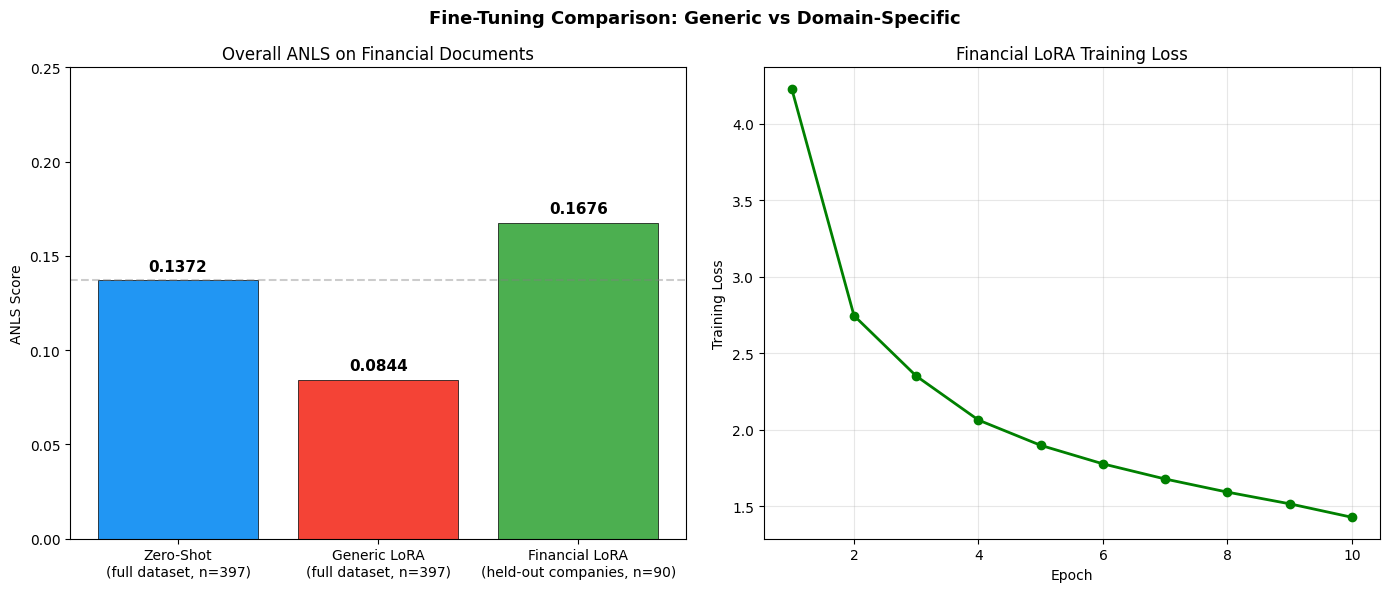

✓ Saved


In [7]:
# ============================================================
# CELL 6: Comparison Chart — All Three Fine-Tuning Settings
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fine-Tuning Comparison: Generic vs Domain-Specific',
             fontsize=13, fontweight='bold')

# --- Plot 1: Overall ---
ax = axes[0]
settings = ['Zero-Shot\n(full dataset, n=397)', 'Generic LoRA\n(full dataset, n=397)', 'Financial LoRA\n(held-out companies, n=90)']
anls_vals = [0.1372, 0.0844, 0.1676]
colors = ['#2196F3', '#F44336', '#4CAF50']
bars = ax.bar(settings, anls_vals, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, anls_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('ANLS Score')
ax.set_title('Overall ANLS on Financial Documents')
ax.set_ylim(0, 0.25)
ax.axhline(y=0.1372, color='gray', linestyle='--', alpha=0.4)

# --- Plot 2: Training loss curve ---
ax = axes[1]
ax.plot(range(1, len(train_losses)+1), train_losses, 'g-o', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Financial LoRA Training Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'financial_finetuning_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")